# **Züri wie neu Waste Report Heatmap**

Author: Tim Berger  
Date: 20.5.2026
<br>
<br>

### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city.  
Reports are sorted in different categories, such as waste or graffiti.   
Illegal deposited waste and littering in the "Abfall/ Sammelstelle" category is reported the most (see category frequency analysis).  
To see where the reports of waste and littering cluster the most, this analysis aims to create a heatmap of the waste and littering reports in Züri wie neu 
<br>
<br>

### Research Question: 
Where do the illegal deposited waste and littering reports in Züri wie neu cluster within the city?
<br>
<br>

### Requirements
See README file
<br>
<br>

### **Import Required Packages and Scripts**

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import math
import contextily as ctx
import cmcrameri.cm as cmc
from matplotlib_scalebar.scalebar import ScaleBar

import notebook_utils

### **Load data**

In [ ]:
# the notebook_utils file contains the functions to load the required data
# if a dataset failed to load, the corresponding url should be checked
# the source and explanation of the url can be found in the README file.

url_zwn = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Zueri_wie_neu?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=zwn_meldungen_p"
url_neighbourhoods = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_v"

zwn_gdf_raw = notebook_utils.import_geografic_data(url_zwn)
neighbourhoods_gdf_raw = notebook_utils.import_geografic_data(url_neighbourhoods)


data loaded successfully
data loaded successfully


### **Clean and Filter the Data**

- clean züri wie neu data

In [ ]:
# filter the züri wie neu data for waste
zwn_waste_gdf = zwn_gdf_raw[zwn_gdf_raw["service_name"]=="Abfall/Sammelstelle"].copy()

# filter for the required columns
zwn_waste_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry", "requested_datetime"]]

# reproject to web mercator to be able to load a basemap later
zwn_waste_gdf = zwn_waste_gdf.to_crs(epsg=3857)

# print dates of the oldest and newest report
print(f"The data contains reports from the {min(zwn_waste_gdf["requested_datetime"]).date().strftime("%d/%m/%Y")} to the {max(zwn_waste_gdf["requested_datetime"]).date().strftime("%d/%m/%Y")}.")

# have a look if everything worked and if there are NA values
zwn_waste_gdf.info()

The data contains reports from the 15/03/2013 to the 21/05/2026.


,service_request_id,title,geometry,requested_datetime
4,6,Arbeitskist,POINT (950544.999 6003574.668),2013-03-15 10:36:53
32,37,Schmiererei,POINT (948340.316 5998354.743),2013-04-04 13:21:06
43,57,Dieses defe,POINT (950879.403 6003875.99),2013-04-16 14:49:45
56,72,Defektes Ve,POINT (948723.144 6006046.207),2013-04-16 17:28:32
68,88,Bitte Abfal,POINT (943502.928 6010044.776),2013-04-17 07:55:59


- clean neighbourhood data

In [ ]:
#filter neighbourhoods data for required columns 
neighbourhoods_gdf = neighbourhoods_gdf_raw[["qname", "qnr", "geometry"]]

# reproject to web mercator to be able to load a basemap later
neighbourhoods_gdf = neighbourhoods_gdf.to_crs(epsg=3857)

# check if everything worked and if there are NA values
neighbourhoods_gdf.info()

### **Calculate Intensity Values**

It was decided here to manually calculate all the intensity values here by iterating through the pixel and report points.  
This approach is really slow and should usually not be used for large datasets.  
It was used here because I prefered to write a code that I completely understand and where I practice the learned topics, then to just let an imported function calculate the heatmap.

In [5]:
# decide for a resolution of the grid [m] and a radius [m] for the kernel which should be considered
resolution = 100
r = 300

# extract the x and y coordinates of all reports
x = list(zwn_waste_gdf.geometry.x)
y = list(zwn_waste_gdf.geometry.y)

# calculate the extend of the map
lower_x = round(min(zwn_waste_gdf.geometry.x)-r)
upper_x = round(max(zwn_waste_gdf.geometry.x)+r)
lower_y = round(min(zwn_waste_gdf.geometry.y)-r)
upper_y = round(max(zwn_waste_gdf.geometry.y)+r)

# create an array with all coordinates
x_coords= np.arange(lower_x, upper_x, resolution)
y_coords= np.arange(lower_y, upper_y, resolution)

# create a mesh grid
mesh_x, mesh_y = np.meshgrid(x_coords, y_coords)


# calculate the centre coordinates of the grid
xcentre = mesh_x+(resolution/2)
ycentre = mesh_y+(resolution/2)


# define the kernel function, to determine how the points should be weighted
def kernel_function(d, r):

    """calculates the weight of a of a point to the heat density of a pixel
    
    this function calculates the weight of a point according to the quartic kernel function
    
    parameters
    --------------
    d : the distance between the pixel centre and the point 
    r : the radius of the kernel that should be considered
    
    returns
    --------------
    float: weight contribution of the point to the value of the pixel """

    dn = d/r
    p = (15/16)*(1-dn**2)**2
    return p

# create a new empty list, which will contain all the intensities
intensity_list = []


# computing density for each grid
for j in range(len(xcentre)):  # iterrates through the rows (as xcentre contains an array for every row with all x values )
    intensity_row = []          #create a new empty list for the row
    for k in range(len(xcentre[0])):    # iterrates through the columns
        kde_value_list = []
        for i in range(len(x)):     # iterrates through all the coordinates of the zwn reports
            # calculate distance between current pixel centre and every zwn report
            d = math.sqrt((xcentre[j][k] - x[i])**2 + (ycentre[j][k] - y[i])**2)
            
            if d <= r:          # if distance is smaller then the kernel radius
                p = kernel_function(d, r)       # calculate the density value with the kernel function
            else:
                p = 0
            kde_value_list.append(p)        
            
        # sum all density values
        total_density = sum(kde_value_list)
        intensity_row.append(total_density)
        
    intensity_list.append(intensity_row)




- create a histogram of all densities to be able to plot it reasonable

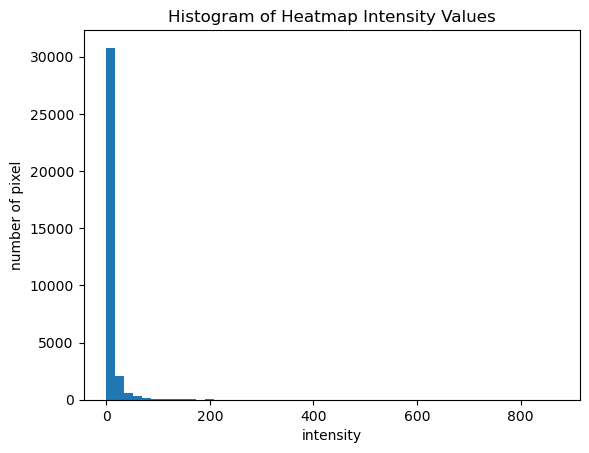

In [6]:
fig, ax = plt.subplots()

#create one list with all intensities 
all_intensities = []
for row in intensity_list:
    for value in row:
        all_intensities.append(value)

# plot the intensities as a histogram
ax.hist(all_intensities, bins=50)
ax.set_title("Histogram of Heatmap Intensity Values")
ax.set_ylabel("number of pixel")
ax.set_xlabel("intensity")

# save figure in the figures folder
fig.savefig("../figures/heatmap_intensity_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

- as the density data is heavily skewed, the bounds of the colormap are manually restricted

In [7]:
# calculate the 99 % quantile
q99 = np.quantile(all_intensities, 0.99)

# clip all values larger than than q99 to q99
intensity_restricted = np.clip(np.array(intensity_list), 0, q99)


### **Plot**

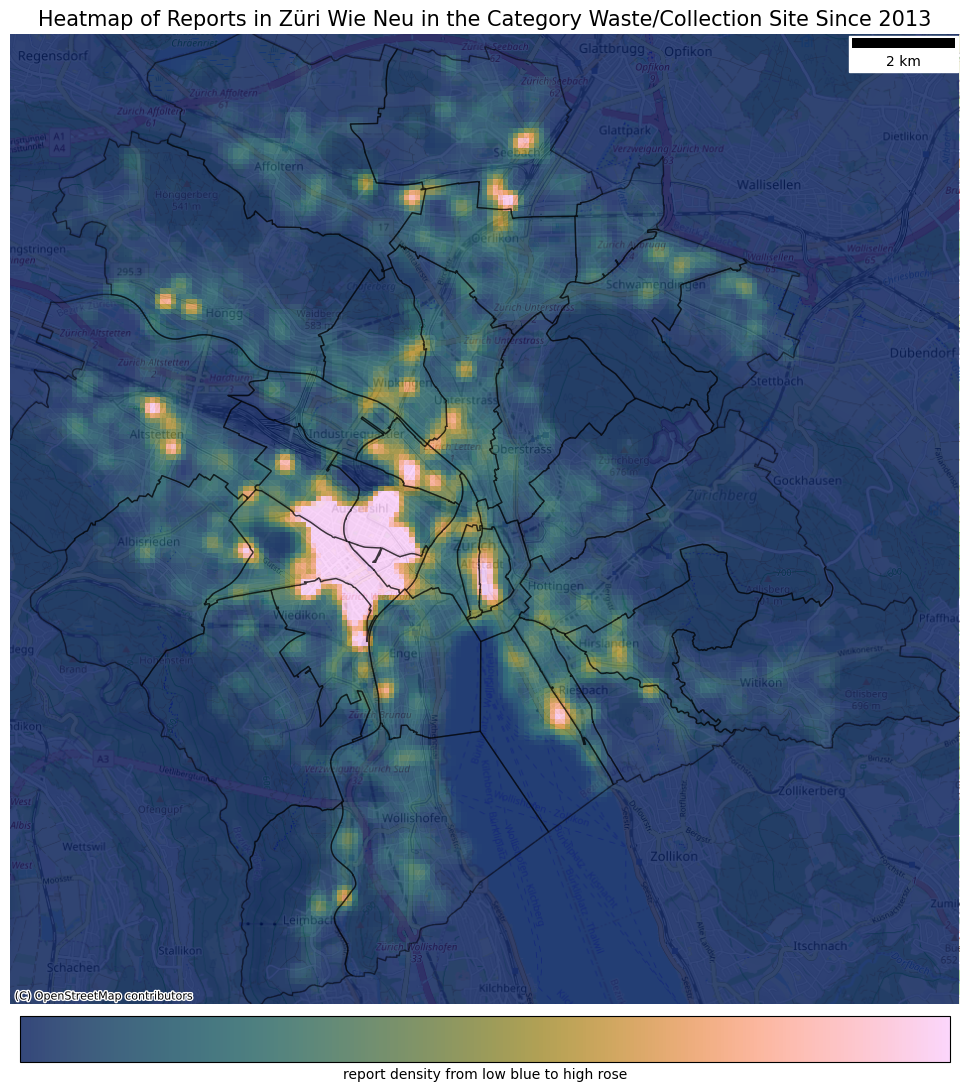

In [15]:
fig, ax = plt.subplots(figsize = (15, 15))


# create the heatmap layer
heatmap = ax.pcolormesh( mesh_x, mesh_y, intensity_restricted, alpha=0.8, cmap=cmc.batlow)

# add a basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.CH)

# remove axis
ax.axis("off")

#set a title
ax.set_title(f"Heatmap of Reports in Züri Wie Neu in the Category Waste/Collection Site Since {min(zwn_waste_gdf["requested_datetime"]).year}", fontsize= 15)

# add neighbourhood boundaries
neighbourhoods_gdf.plot(ax= ax, facecolor="none", alpha=0.5)

# add scalebar
scalebar = ScaleBar(1)
ax.add_artist(scalebar)

# add colorbar
plt.colorbar(heatmap, ax=ax, label="report density from low blue to high rose", location="bottom", ticks=[], shrink=0.8, pad= 0.01)

# save figure in the figures folder
fig.savefig("../figures/heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### **Results**

On the heatmap one large hotspot of waste reports can be observed, located around the crossing of the Badenerstrasse and Seebahnstrasse with a radius of about 1 km. Apart from that there are several small hotspots in the suburban area such as Oerlikon, Höngg, Altstetten and Seefeld.  In the Rathaus neighborhood there is a stretched middle size hotspot along the Niederdorf.  Larger area patterns show that there are few to no reports located in the forest areas of Uetliberg, Züriberg and Hönggerberg. 